In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

## TOV Equation Solver

### Equations to Solve

The **TOV-equation** is given by
\begin{align}
    \frac{dp}{dr} = -\frac{(p+\rho)(m+4\pi r^3 p)}{r(r-2m)}\tag{TOV}
\end{align}

Given a background metric:
\begin{align}
    ds^2 = -e^\nu dt^2 + e^{\lambda} dr^2 + r^2d\Omega^2,\tag{BG metric}
\end{align}
one is also able to obtain the $\nu$ equation:
\begin{align}
    \frac{d\nu}{dr} = 2\frac{m+ 4\pi r^3 p}{r(r-2m)}\tag{$\nu$}
\end{align}
Also note that we have the **conservation equation**:
\begin{align}
    \frac{dm}{dr} = 4\pi r^2 \rho\tag{Conservation}
\end{align}

We solve the conservation equation and the TOV equation first, to obtain numerical expression of $\rho, p, m$ of $r$, then match the boundary condition at $r = R$. 

### Initial Conditions

We set up initial conditions for solving the conservation equation and the TOV equation.

Given the asymptotic behavior, given a small r, $r_\epsilon$, the initial condition of $m, p, \nu$ are given by:
$$m = \frac{4\pi}{3}\rho_c(p_c)r_\epsilon^3$$
$$p = p_c - \frac{2\pi}{3}(\rho_c + p_c)(\rho_c + 3p_c)r_\epsilon^2$$
$$\nu = \nu_c + \frac{4\pi}{3}(3p_c + \rho_c)r_\epsilon^2$$

In [ ]:
# Defining a Polytropic EOS
def PolyEOS(p, n, K):
    rr = (p/K)**(n/(n+1))
    return rr

def EnergyEOS(p,n,K):
    rr = ((1+np.sqrt(4*K*p))**2-1)/(4*K)
    return rr

# Initial conditions given the asymptotic behavior at small r limit

# Setting a small initial r to avoid dividing by 0
eps = 10**(-5)
K = 240 
n = 2.54

# Setting the zeroth order terms
p_c =  8.262e-06
rho_c = PolyEOS(p_c, n, K)

print(K, p_c, rho_c)
# Initial condition of each variable given the small r
p = p_c - (2*np.pi/3) * (p_c + rho_c) * (3*p_c + rho_c) * eps**2
m = (4*np.pi/3) * rho_c * eps**3


240 8.262e-06 4.416738093659949e-06


### Solving for $m, p, \rho$

In [3]:
# The set of TOV equation and the conservation equation
def tov_rhs(r, y, eos, n, K):
    m, p = y[0], y[1]
    rhoEnergy = eos(p, n, K)
    # rhoMass = (-1 + np.sqrt(1 + 4*K*rhoEnergy)) / (2*K)    # solution to the n = 1 case
    # rhoMass = rhoEnergy + K*rhoEnergy**2 

    dm_dr = 4 * np.pi * r**2 * rhoEnergy
    dp_dr = - (rhoEnergy + p) * (m + 4*np.pi*(r**3)*p) / (r * (r - 2*m))
    
    return [dm_dr, dp_dr]

def rk4_step(func, r, y, h, eos=EnergyEOS, n=n, K=K):
    k1 = np.array(func(r, y, eos, n, K))
    k2 = np.array(func(r + h/2, y + h*k1/2, eos, n, K))
    k3 = np.array(func(r + h/2, y + h*k2/2, eos, n, K))
    k4 = np.array(func(r + h, y + h*k3, eos, n, K))
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


In [4]:
# Step size
h = 10**(-3)

# List to document solution and radius.
# Since we don't know the steps to reach the stellar surface so fixed-length array is not used.
Sol = [np.array([m,p])]
R_l = [eps]

In [5]:
counter = 0

while np.log10(Sol[0][1]/Sol[-1][1]) <= 9:
    newStep = rk4_step(tov_rhs, R_l[-1], Sol[-1], h, EnergyEOS, n, K)
    Sol.append(newStep)
    R_l.append(R_l[-1] + h)
    counter += 1
    # print(newStep)

    if counter % 100000 == 0:
         print(newStep)
# print(counter)

/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_45244/4189607106.py:7: RuntimeWarning: invalid value encountered in sqrt
  rr=((1+np.sqrt(4*K*p))**2-1)/(4*K)


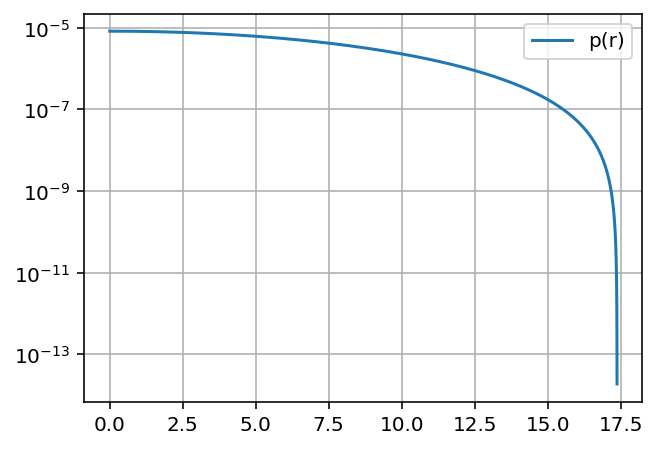

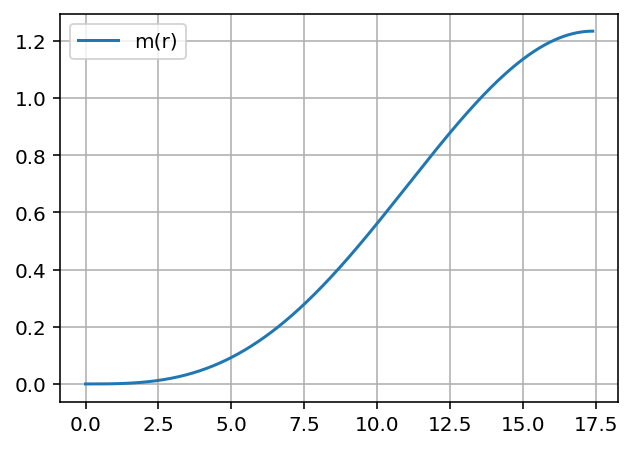

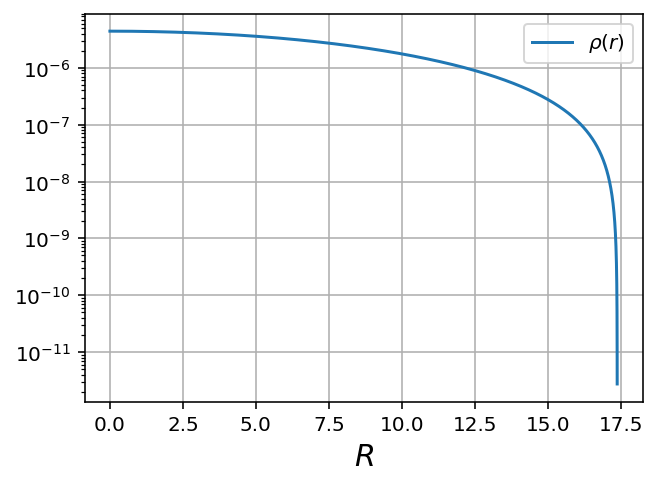

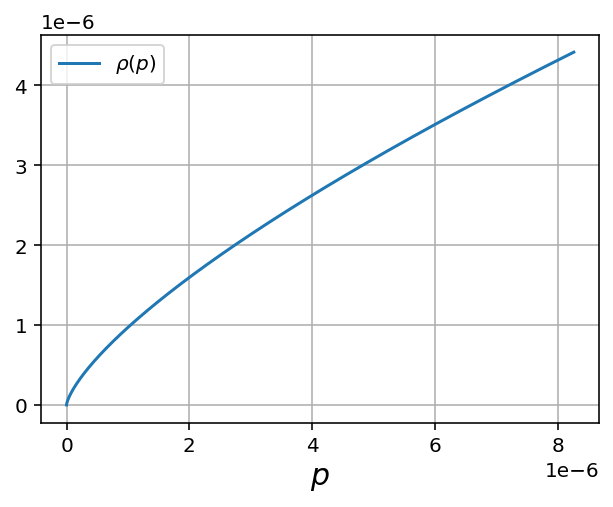

In [6]:
plt.figure(figsize=(5,3.5), dpi=144)
plt.plot(R_l[:], np.array(Sol)[:,1], label="p(r)")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(5,3.5), dpi=144)
plt.plot(R_l[:], np.array(Sol)[:,0], label="m(r)")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(5,3.5), dpi=144)
plt.plot(R_l[:], PolyEOS(np.array(Sol)[:,1], n, K), label=r"$\rho(r)$")
plt.xlabel(r"$R$", fontsize=15)
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

plt.figure(figsize=(5,3.5), dpi=144)
plt.plot(np.array(Sol)[:,1], PolyEOS(np.array(Sol)[:,1], n, K), label=r"$\rho(p)$")
plt.xlabel(r"$p$", fontsize=15)
plt.legend()
# plt.yscale("log")
plt.grid()
plt.show()

## Reproducing result in [0503119](https://arxiv.org/pdf/gr-qc/0503119)

![result to reproduce](./0503119-f2b.png)

Note that the radius and mass are in km and solar mass. We recall that the Schwarzschild radius $R_S(M_\odot)$ of a $1M_\odot$ blackhole is about 3.0km.

In the paper, $\Gamma := 2$, which means the polytropic index $n = 1$, and $K_p = 1.6 × 10^5$ in the cgs unit ($\text{g}^{-1}\text{cm}^5\text{s}^2$). The Polytropic EOS is given by:
$$P = K\rho^2$$
We first convert the quantities to geometric unit.

In [7]:
G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=PolyEOS):

    # km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2            
    # km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)               
    # Polytropic EOS, km^-2
    rho_geom = eos(p_geom, n, K_geom)               

    return K_geom, p_geom, rho_geom

# The input mass has unit km in geometric units, and we want to express it in solar mass
def mass_g2Msun(m_km):
    m_cgs = m_km * cm2km
    m_msun = m_cgs / G_cgs * (c_cgs**2) / M_sun_cgs

    return m_msun

In [8]:
d_num = 20
K_cgs = 1.6e5
n = 1
stepArr = [3.5]

RR = []
MM = []

SolArr = []
RArr = []



for step_ind in stepArr:
    h = 10**(-step_ind) 
    R_arr = np.zeros(d_num)
    M_arr = np.zeros(d_num)
    Rho_arr = np.zeros(d_num)

    for i, P in tqdm(enumerate(np.logspace(33.5, 36.5, d_num))):

        
        K, p_c, rho_c = cgs_to_geom(P, n, K_cgs, eos=EnergyEOS)
        
        # Initial Condition
        p0 = p_c - (2*np.pi/3) * (p_c + rho_c) * (3*p_c + rho_c) * eps**2
        m0 = (4*np.pi/3) * rho_c * eps**3

        Sol = [np.array([m0,p0])]
        R_l = [eps]

        counter = 0
        extra = 0
        while (np.log10(Sol[0][1]/Sol[-1][1]) <= 10.1):
            newStep = rk4_step(tov_rhs, R_l[-1], Sol[-1], h, EnergyEOS, n, K)
            Sol.append(newStep)
            R_l.append(R_l[-1] + h)
            counter += 1

            # if not (np.log10(Sol[0][1]/Sol[-1][1]) <= 10): 
            #     extra += 1
        
        SolArr.append(Sol)
        RArr.append(R_l)
        
        R_arr[i] = R_l[-2]
        Rho_arr[i] = rho_c
        M_arr[i] = mass_g2Msun(Sol[-2][0])
    
    RR.append(R_arr)
    MM.append(M_arr)

0it [00:00, ?it/s]/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_45244/4189607106.py:7: RuntimeWarning: invalid value encountered in sqrt
  rr=((1+np.sqrt(4*K*p))**2-1)/(4*K)
20it [00:12,  1.60it/s]


In [10]:
# Sol[-22:]

In [ ]:
# import pickle

# with open("./numpyArr/PMSol.pkl", "wb") as f:                        
#     pickle.dump(SolArr, f, protocol=pickle.HIGHEST_PROTOCOL)

# with open("./numpyArr/Rgrid.pkl", "wb") as f:                        
#     pickle.dump(RArr, f, protocol=pickle.HIGHEST_PROTOCOL)


In [54]:
# with open("./numpyArr/Rgrid.pkl", "rb") as f:                        # binary read
#     my_list = pickle.load(f)

In [11]:
MM

[array([0.53946704, 0.62361048, 0.716351  , 0.81700469, 0.92429647,
        1.03628096, 1.15031736, 1.26312402, 1.370932  , 1.46974082,
        1.55565708, 1.62527181, 1.67601437, 1.70641782, 1.71624633,
        1.70646595, 1.67907536, 1.63684149, 1.58299757, 1.52095708])]

[0.53946704 0.62361048 0.716351   0.81700469 0.92429647 1.03628096
 1.15031736 1.26312402 1.370932   1.46974082 1.55565708 1.62527181
 1.67601437 1.70641782 1.71624633 1.70646595 1.67907536 1.63684149
 1.58299757 1.52095708] [18.17867936 17.96079843 17.70939735 17.42131386 17.09401812 16.72498032
 16.31325177 15.85883247 15.36298733 14.82919486 14.26188225 13.66832273
 13.05610578 12.43471822 11.81396311 11.20427598 10.61545988 10.05668541
  9.53680697  9.06309777]


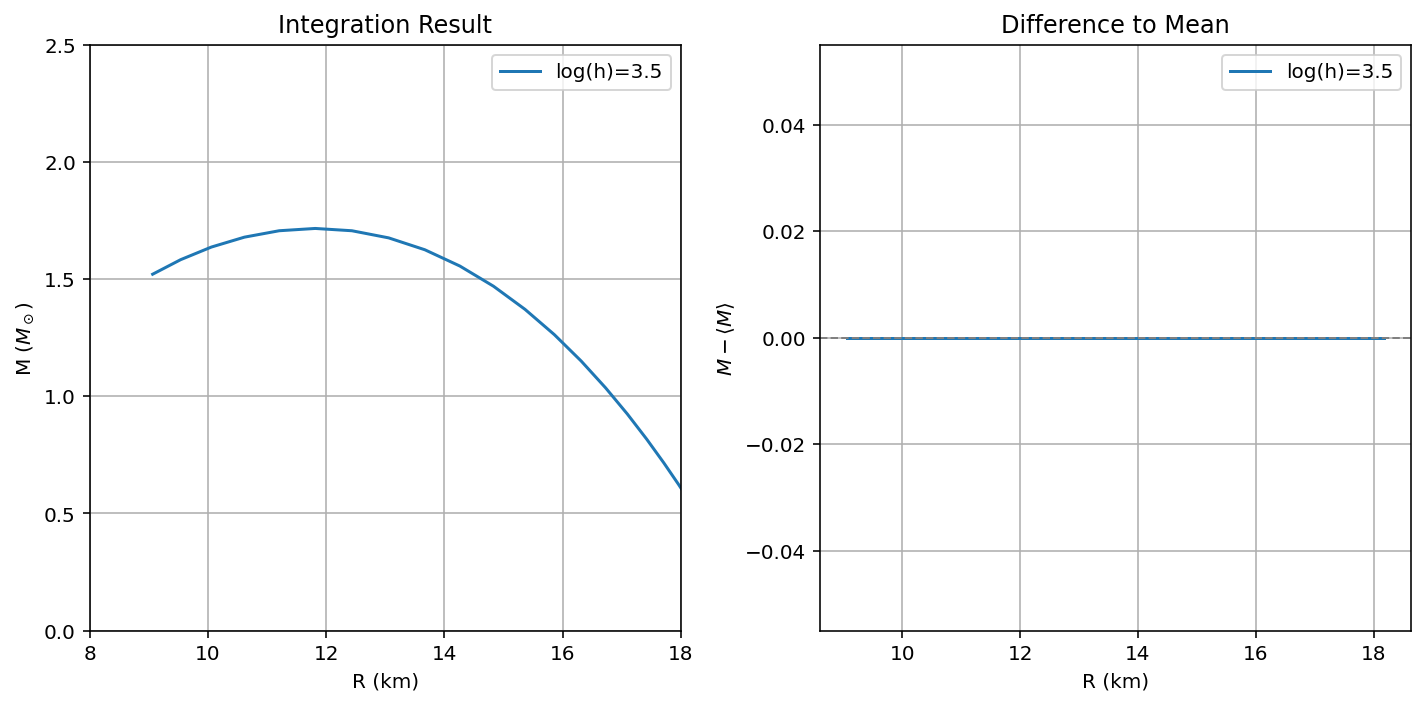

In [13]:
# Compute mean at each data point
M_stack = np.stack(MM)  
R_stack = np.stack(RR)  
M_mean = np.mean(M_stack, axis=0)
R_mean = np.mean(R_stack, axis=0)

# Compute differences
M_diff = M_stack - M_mean  
R_diff = R_stack - R_mean  

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=144)

# Original plot
axs[0].set_xlim(8, 18)
axs[0].set_ylim(0, 2.5)
axs[0].grid()
axs[0].set_xlabel("R (km)")
axs[0].set_ylabel(r"M ($M_\odot$)")
for M, R, H in zip(MM, RR, stepArr):
    print(M, R)
    axs[0].plot(R, M, label=f"log(h)={H}")
axs[0].legend()
axs[0].set_title("Integration Result")

# Difference to mean in log scale
for diff, H in zip(M_diff, stepArr):
    axs[1].plot(R_arr, diff, label=f"log(h)={H}")
axs[1].axhline(0, color='gray', ls='--', linewidth=1)
axs[1].set_xlabel("R (km)")
axs[1].set_ylabel(r"$M - \langle M \rangle$")
axs[1].set_title("Difference to Mean")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

![result to reproduce](./0503119-f2b.png)

## Matching $\nu$ at stellar surface

With the numerical expression of $p$, $m$, one is then able to numerically integrate to obtain a numerical expression of $\nu$, with the differential expression:
\begin{align}
    \frac{d\nu}{dr} = 2\frac{m+ 4\pi r^3 p}{r(r-2m)}\tag{$\nu$}
\end{align}
We require the expression of $\nu$ to be continuous and by Birkhoff's theorem, the exterior solution must be Schwarzschild. Since there is no $\nu$ term explicitly in the term above, it is shift-invariant - meaning that the value of the zeroth order term $\nu_c$ does not impact the behavior of the differential equation.

Given by the Schwarzschild metric,  $\tilde{\nu}(R) = \ln\left|1-\frac{2M}{R}\right|$. WLOG we can pick 0 as the value for the $\nu_c$ we integrate with, at $r = R$, we obtain $\nu(R)$. With the shift invariant feature, one obtain the constant to be added to the zeroth order term by $C_\nu = \tilde\nu(R) - \nu(R)$.

In [22]:
def nu_rhs(r, y, p, m):
    rr = 2 * (m + 4*np.pi*(r**3) * p) / (r*(r-2*m))
    return rr

# the new rk4 function for computing \nu numerically (with 6 params, so the previous is not overridden)
def rk4_step_nu(func, r, y, h, p, m):
    k1 = np.array(func(r, y, p, m))
    k2 = np.array(func(r + h/2, y + h*k1/2, p, m))
    k3 = np.array(func(r + h/2, y + h*k2/2, p, m))
    k4 = np.array(func(r + h, y + h*k3, p, m))
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

In [23]:
# The initial \nu_c we pick is 0
Sol_nu = np.zeros(len(R_l)) 

Sol_arr = np.array(Sol)

counter = 0
for i, r in enumerate(R_l[:-1]):

    newStep = rk4_step_nu(nu_rhs, r, Sol_nu[i], h, Sol_arr[i,1], Sol_arr[i,0])
    Sol_nu[i+1] = newStep
    
    counter += 1
    if counter % 1000 == 0: print(counter, newStep)



1000 0.005747631884736777
2000 0.022930194370833257
3000 0.05132481900806293
4000 0.09056061602206533
5000 0.1401198308333407
6000 0.19933993088568552
7000 0.2674172397515634
8000 0.34341295717094605
9000 0.42626266486225667
10000 0.5147906228187766
11000 0.6077301982553522
12000 0.7037514949119078
13000 0.8014965282535494
14000 0.8996210742025527
15000 0.9968407401835301
16000 1.0919772379768289
17000 1.1839998204910467
18000 1.272056883447655
19000 1.355494019407314
20000 1.4338570582213896
21000 1.506881155790843
22000 1.5744690428508914
23000 1.6366626182024326
24000 1.6936120893558193
25000 1.7455461005593598
26000 1.7927451604343945
27000 1.8355195572180047
28000 1.874192051832


In [24]:
# Calculating and matching the actual \nu at the stellar surface
nu_R = np.log(1-2*np.array(Sol)[-2,0]/R_l[-2])
print(nu_R)
Sol_nu += (nu_R - Sol_nu[-2])

-0.6846981983683512


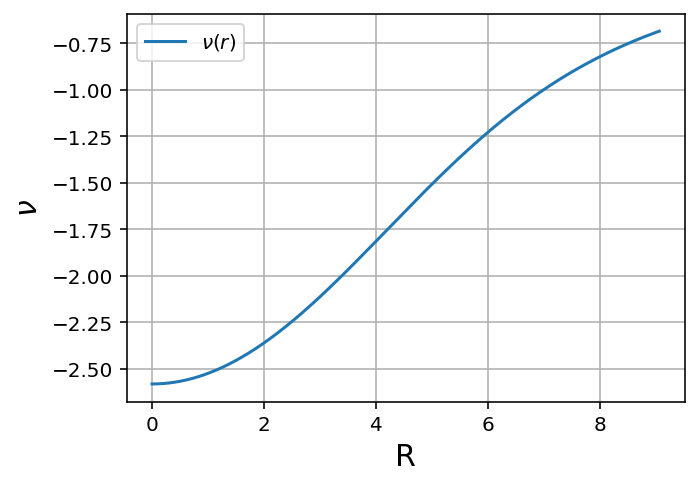

In [25]:
plt.figure(figsize=(5,3.5), dpi=144)

plt.plot(R_l[:], Sol_nu, label=r"$\nu(r)$")
# plt.plot(R_l[:], Sol_nu + nu_R, label=r"$\nu(r)$")

plt.xlabel("R", fontsize=15)
plt.ylabel(r"$\nu$", fontsize=15)

plt.grid()
plt.legend();
# plt.yscale("symlog")

In [ ]:

NuGrid = []

for sol_raw, r_raw in zip(SolArr, RArr):
    r_arr = np.asarray(r_raw[:-1])
    sol_arr = np.asarray(sol_raw[:-1])

    m_arr = sol_arr[:, 0]
    p_arr = sol_arr[:, 1]

    denom = r_arr * (r_arr - 2.0 * m_arr)
    dnudr = 2.0 * (m_arr + 4.0 * np.pi * (r_arr ** 3) * p_arr) / np.where(denom == 0.0, np.nan, denom)

    if np.isnan(dnudr[0]):
        dnudr[0] = dnudr[1]
    dnudr = np.nan_to_num(dnudr, nan=0.0, posinf=0.0, neginf=0.0)

    nu_profile = np.zeros_like(r_arr)
    if r_arr.size > 1:
        dr = np.diff(r_arr)
        averaged = 0.5 * (dnudr[1:] + dnudr[:-1])
        nu_profile[1:] = np.cumsum(averaged * dr)

    nu_profile -= nu_profile[-1]
    NuGrid.append(nu_profile)

with open("./numpyArr/NuGrid.pkl", "wb") as f:
    pickle.dump(NuGrid, f, protocol=pickle.HIGHEST_PROTOCOL)



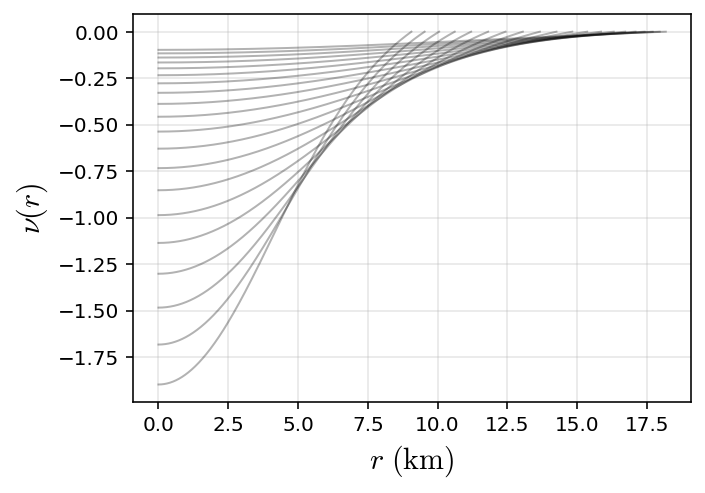

In [36]:

plt.figure(figsize=(5, 3.5), dpi=144)
plt.rcParams["mathtext.fontset"] = "cm"

for r_raw, nu_arr in zip(RArr, NuGrid):
    r_arr = np.asarray(r_raw[:-1])
    nu_arr = np.asarray(nu_arr)
    plt.plot(r_arr, nu_arr, lw=1.0, alpha=0.3, color="black")

plt.xlabel(r"$r\ (\mathrm{km})$", fontsize=15)
plt.ylabel(r"$\nu(r)$", fontsize=15)
plt.grid(alpha=0.3)
plt.show()



## Check Loaded $\nu$

In [30]:
import pickle

In [32]:
with open("./numpyArr/NuGrid.pkl", "rb") as f:                        
    # binary read
    NuGridLoad = pickle.load(f)

with open("./numpyArr/Rgrid.pkl", "rb") as f:                        
    # binary read
    Rgrid = pickle.load(f)

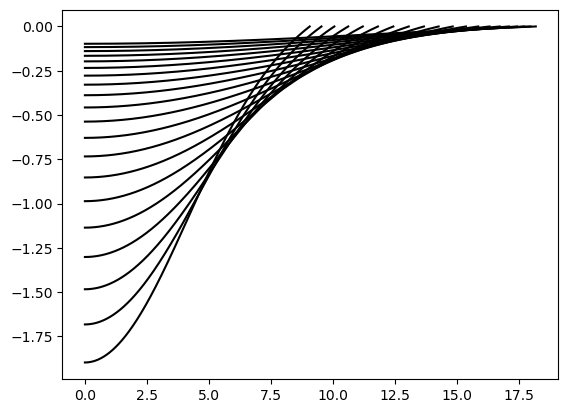

In [35]:
for nu, r in zip(NuGridLoad, Rgrid):
    plt.plot(r[:min(len(nu), len(r))], nu, color = "black")